In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import math

c:\Users\yug\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


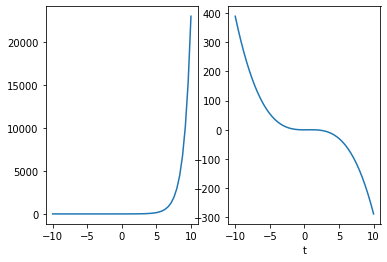

In [5]:
def func0(x,t): # func is a function of x and t, func returns dx/dt, so x(t) is our main function to find.
    dxdt = np.exp(t)
    return dxdt

def func1(x,t):
    dxdt = t-t**2
    return dxdt

def odesolve(func, x0, t,step): # t is array of inputs to find at.
    solved = np.zeros(len(t)) # array containing solved values of x(t) at t
    i=0
    for t0 in t:
        if(t0>x0):
            kh = np.linspace(x0,t0,step)
            xk = x0 # xk will be equal to t0 at some point
            h = kh[1]-kh[0] # step size
            
            for k in kh: #for small increments in xk till xk=t0
                xk = xk + h*func(xk,k)
            solved[i] = xk
            i+=1
        elif(t0<x0):
            kh = np.linspace(t0,x0,step)
            xk = x0 
            h = kh[1]-kh[0]

            for k in kh: 
                xk = xk - h*func(xk,k)
            solved[i] = xk
            i+=1
        else:
            solved[i]=x0
            i+=1
            continue

    return solved
    
y00=1
y01=0
step=100
t = np.linspace(-10,10)

x0 = odesolve(func0,y00,t,step)
x1 = odesolve(func1,y01,t,step)

figure, axis = plt.subplots(1,2)
plt.xlabel("t")
axis[0].plot(t,x0)
axis[1].plot(t,x1)